## Big Data Analytics of E-Commerce Purchase History for Customer Behavior and Sales Trend Analysis

**DATASET**

**Description**: eCommerce Purchase History from Electronics Store(kaggle) This dataset contains purchase data from April 2020 to November 2020 from a large home appliances and electronics online store.Each row in the file represents an event. All events are related to products and users. Each event is like many-to-many relation between products and users. Data collected by Open CDP project. Feel free to use open source customer data platform.<br>

**Dataset Link**:https://www.kaggle.com/datasets/mkechinov/ecommerce-purchase-history-from-electronics-store

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Import Dataset

In [10]:
df = pd.read_csv('./data/kz.csv')
print(df.shape)

(2633521, 8)


## EDA

In [11]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2633521 entries, 0 to 2633520
Data columns (total 8 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     str    
 1   order_id       int64  
 2   product_id     int64  
 3   category_id    float64
 4   category_code  str    
 5   brand          str    
 6   price          float64
 7   user_id        float64
dtypes: float64(3), int64(2), str(3)
memory usage: 270.4 MB
None


In [12]:
df.isnull().sum()

event_time             0
order_id               0
product_id             0
category_id       431954
category_code     612202
brand             506005
price             431954
user_id          2069352
dtype: int64

In [13]:
df.describe(include='all')

,event_time,order_id,product_id,category_id,category_code,brand,price,user_id
count,2633521,2.633521e+06,2.633521e+06,2.201567e+06,2021319,2127516,2.201567e+06,5.641690e+05
unique,1316174,NaN,NaN,NaN,510,23021,NaN,NaN
top,1970-01-01 00:33:40 UTC,NaN,NaN,NaN,electronics.smartphone,samsung,NaN,NaN
freq,19631,NaN,NaN,NaN,357682,358928,NaN,NaN
mean,NaN,2.361783e+18,1.674080e+18,2.273827e+18,NaN,NaN,1.540932e+02,1.515916e+18
std,NaN,1.716538e+16,3.102249e+17,2.353247e+16,NaN,NaN,2.419421e+02,2.377083e+07
min,NaN,2.294360e+18,1.515966e+18,2.268105e+18,NaN,NaN,0.000000e+00,1.515916e+18
25%,NaN,2.348807e+18,1.515966e+18,2.268105e+18,NaN,NaN,1.456000e+01,1.515916e+18
50%,NaN,2.353254e+18,1.515966e+18,2.268105e+18,NaN,NaN,5.553000e+01,1.515916e+18
75%,NaN,2.383131e+18,1.515966e+18,2.268105e+18,NaN,NaN,1.967400e+02,1.515916e+18


In [14]:
print("Exact duplicate rows:", df.duplicated().sum())
print("Total rows:", len(df))

Exact duplicate rows: 675
Total rows: 2633521


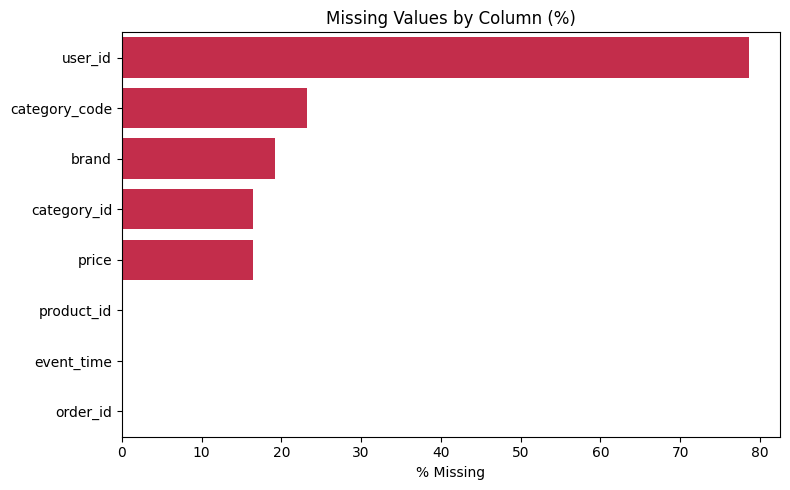

In [15]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

plt.figure(figsize=(8,5))
sns.barplot(x=missing_pct.values, y=missing_pct.index, color="crimson")
plt.title("Missing Values by Column (%)")
plt.xlabel("% Missing")
plt.ylabel('')
plt.tight_layout()
plt.savefig('./images/missing_values.png', dpi=300)
plt.show()

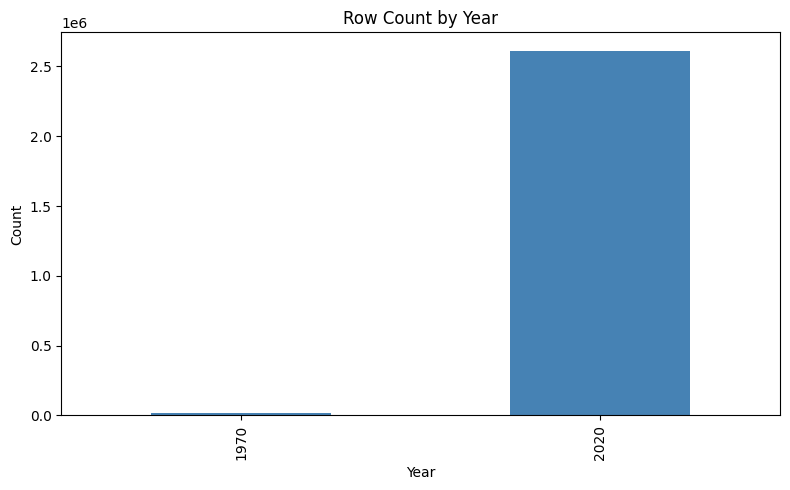

In [16]:
df["event_time_parsed"] = pd.to_datetime(df["event_time"], errors="coerce")
df["year"] = df["event_time_parsed"].dt.year

plt.figure(figsize=(8,5))
df["year"].value_counts().sort_index().plot(kind="bar", color="steelblue")
plt.title("Row Count by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig('./images/row_count_by_year.png')
plt.show()

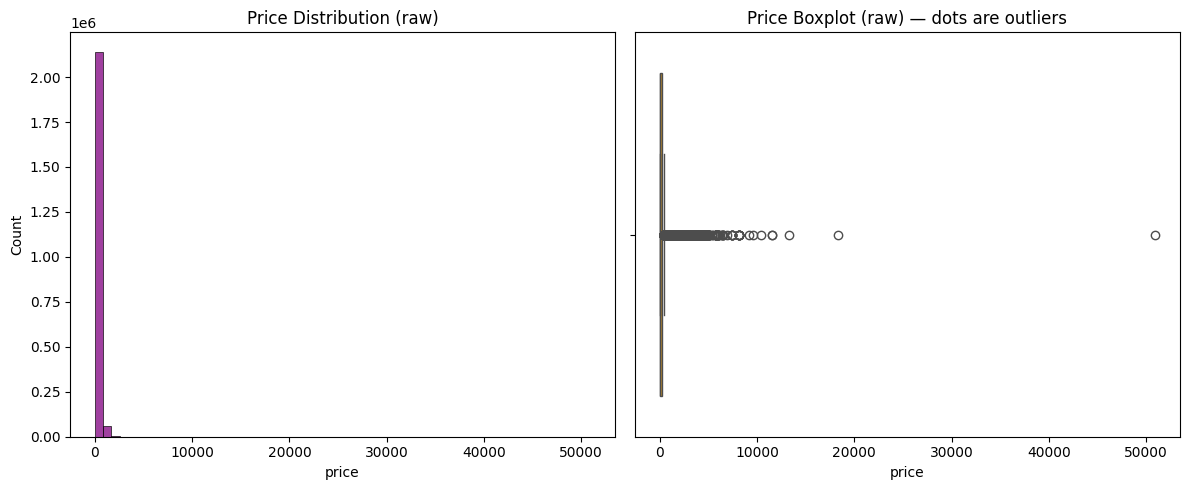

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.histplot(df["price"].dropna(), bins=60, ax=axes[0], color="purple")
axes[0].set_title("Price Distribution (raw)")

sns.boxplot(x=df["price"].dropna(), ax=axes[1], color="orange")
axes[1].set_title("Price Boxplot (raw) — dots are outliers")
plt.tight_layout()
plt.savefig('./images/price_distribution.png', dpi=300)
plt.show()

## Pre-processing & Cleaning the data

In [18]:
# Duplicate removal
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicated rows")

Removed 675 duplicated rows


In [19]:
# Conversion of timestamp to datetime
df['event_time'] = pd.to_datetime(df['event_time'], errors='coerce')

In [20]:
# Drop rows with the 1970-01-01 timestamp 
before = len(df)
df = df[df['event_time'].dt.year > 2000]
print(f"Removed {before - len(df)} rows with invalid timestamps")

Removed 19631 rows with invalid timestamps


In [21]:
# Droping rows with missing user_id or price
before = len(df)
df = df.dropna(subset=["user_id", "price"])
print(f"Removed {before - len(df)} rows missing user_id or price")

Removed 2051027 rows missing user_id or price


In [22]:
# Handle rest missing in category columns and brand column
df['category_code'] = df['category_code'].fillna('unknown')
df['brand'] = df['brand'].fillna('unknown')

In [23]:
# Remove non-positive prices
df = df[df['price'] > 0]

In [24]:
# Handle price outliers using the IQR method
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

before = len(df)
df = df[(df["price"] >= lower_bound) & (df["price"] <= upper_bound)]
print(f"Removed {before - len(df)} price outliers (IQR method)")

Removed 43596 price outliers (IQR method)


In [25]:
# Group rare brands into "Other" and user_id to int64
brand_counts = df["brand"].value_counts()

rare_brands = brand_counts[brand_counts < brand_counts.quantile(0.10)].index
df["brand"] = df["brand"].apply(lambda b: "Other" if b in rare_brands else b)
df["user_id"] = df["user_id"].astype("int64")

In [26]:
df.shape

(518553, 10)

## Feature engineering

In [27]:
df['purchase_month'] = df['event_time'].dt.to_period('M')
df['purchase_day'] = df['event_time'].dt.day_name()
df['purchase_hour'] = df['event_time'].dt.hour

C:\Users\HellKM\AppData\Local\Temp\ipykernel_9508\3420794786.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['purchase_month'] = df['event_time'].dt.to_period('M')


In [28]:
# Per-user aggregation features (used later for spending ananlysis and PCA)
user_features = df.groupby('user_id').agg(
    total_spending=("price", "sum"),
    avg_spending=("price", "mean"),
    purchase_frequency=("order_id", "nunique"),
    max_price=("price", "max")
).reset_index()

user_features.head()

,user_id,total_spending,avg_spending,purchase_frequency,max_price
0,1515915625439952128,416.64,416.640,1,416.64
1,1515915625440038400,56.43,28.215,2,35.39
2,1515915625440051456,2009.60,200.960,5,432.62
3,1515915625440099840,2075.72,103.786,17,624.98
4,1515915625440121600,182.83,91.415,2,138.87


In [29]:
df.shape

(518553, 13)

## EDA-Extended

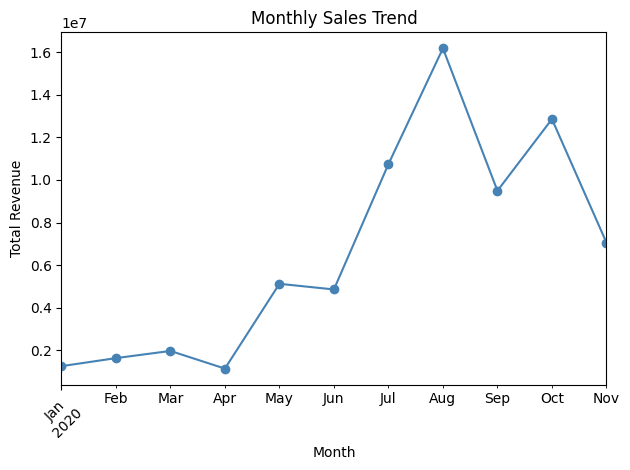

In [30]:
monthly_sales = df.groupby("purchase_month")["price"].sum().sort_index()

plt.figure()
monthly_sales.plot(kind="line", marker="o", color="steelblue")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("./images/monthly_sales_trend.png", dpi=200)
plt.show()

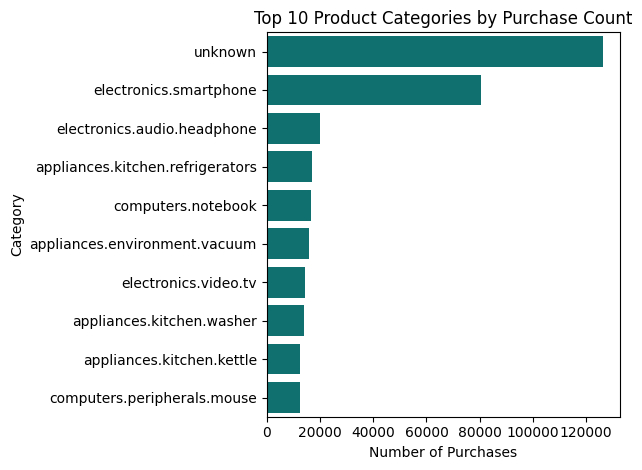

In [31]:
top_categories = df["category_code"].value_counts().head(10)

plt.figure()
sns.barplot(x=top_categories.values, y=top_categories.index, color="teal")
plt.title("Top 10 Product Categories by Purchase Count")
plt.xlabel("Number of Purchases")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig("./images/top_categories.png", dpi=200)
plt.show()

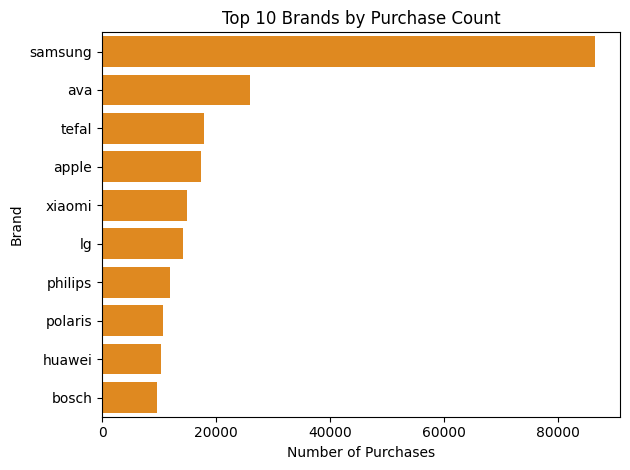

In [32]:
top_brands = df[df["brand"] != "unknown"]["brand"].value_counts().head(10)

plt.figure()
sns.barplot(x=top_brands.values, y=top_brands.index, color="darkorange")
plt.title("Top 10 Brands by Purchase Count")
plt.xlabel("Number of Purchases")
plt.ylabel("Brand")
plt.tight_layout()
plt.savefig("./images/top_brands.png", dpi=200)
plt.show()

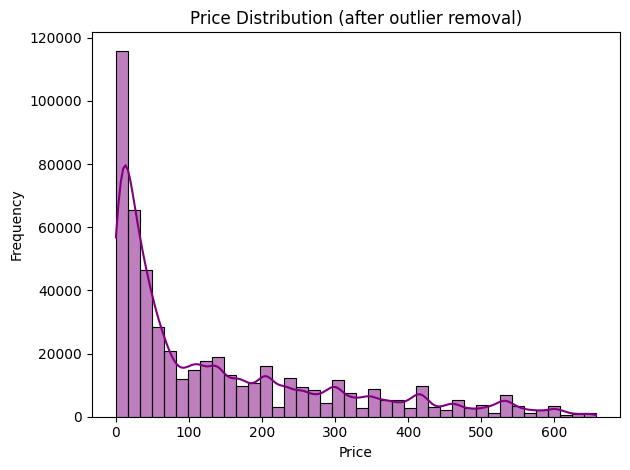

In [33]:
plt.figure()
sns.histplot(df["price"], bins=40, kde=True, color="purple")
plt.title("Price Distribution (after outlier removal)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("./images/price_distribution.png", dpi=200)
plt.show()

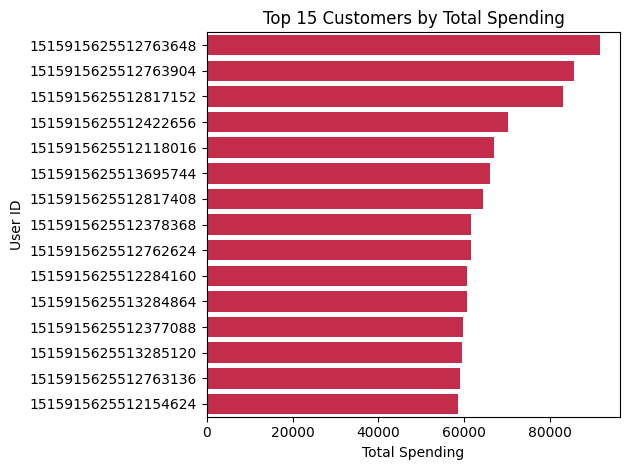

In [34]:
top_customers = user_features.sort_values("total_spending", ascending=False).head(15)

plt.figure()
sns.barplot(x="total_spending", y="user_id", data=top_customers, orient="h",
            order=top_customers["user_id"].astype(str), color="crimson")
plt.title("Top 15 Customers by Total Spending")
plt.xlabel("Total Spending")
plt.ylabel("User ID")
plt.tight_layout()
plt.savefig("./images/top_customers.png", dpi=200)
plt.show()

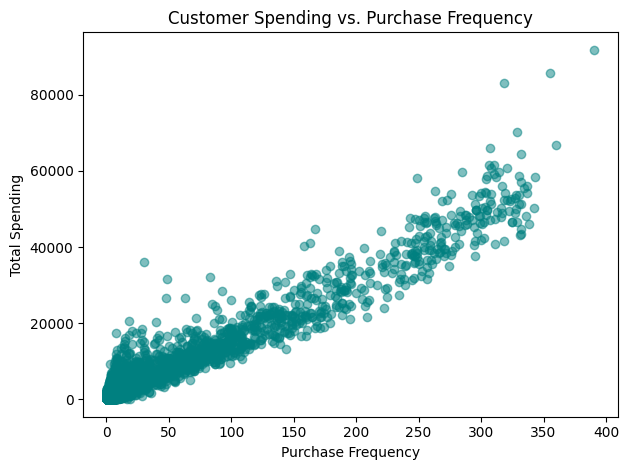

In [35]:
plt.figure()
plt.scatter(user_features["purchase_frequency"], user_features["total_spending"],
            alpha=0.5, color="teal")
plt.title("Customer Spending vs. Purchase Frequency")
plt.xlabel("Purchase Frequency")
plt.ylabel("Total Spending")
plt.tight_layout()
plt.savefig("./images/spending_vs_frequency.png", dpi=200)
plt.show()

## Dimention Reduction with PCA

In [36]:
pca_features = user_features[[
    "total_spending", 
    "avg_spending",
    "purchase_frequency", 
    "max_price"
]]

# Standardize before PCA (required, since PCA is scale-sensitive)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(pca_features)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_features)

user_features["PC1"] = principal_components[:, 0]
user_features["PC2"] = principal_components[:, 1]

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance captured by 2 components: {:.2f}%".format(
    pca.explained_variance_ratio_.sum() * 100))

Explained variance ratio: [0.55015343 0.39464786]
Total variance captured by 2 components: 94.48%


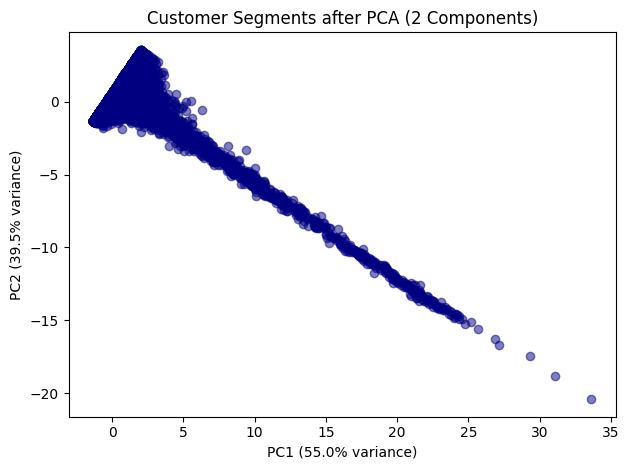

In [37]:
plt.figure()
plt.scatter(user_features["PC1"], user_features["PC2"], alpha=0.5, color="navy")
plt.title("Customer Segments after PCA (2 Components)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.tight_layout()
plt.savefig("./images/pca_customer_segments.png", dpi=200)
plt.show()

In [38]:
df.shape

(518553, 13)